# <p style="font-family:newtimeroman;font-size:150%;text-align:center;color:#8b4513;">Pre-Processing</p>

In [ ]:
import pandas as pd
import re
df = pd.read_csv('Reviews.csv')
df.head()

,tweet_text
0,Tekanan jual meningkat 😢
1,Sentimen global negatif tekan pasar #MSCI
2,IHSG ditutup mixed hari ini #IHSG 📉
3,Investor wait and see #MSCI cek selengkapnya d...
4,IHSG terkoreksi tajam #IHSG


In [2]:
print(df.columns)

Index(['tweet_text'], dtype='object')


In [ ]:
df['Text'] = df['Text'].str.lower()
df.head()

,tweet_text
0,tekanan jual meningkat 😢
1,sentimen global negatif tekan pasar #msci
2,ihsg ditutup mixed hari ini #ihsg 📉
3,investor wait and see #msci cek selengkapnya d...
4,ihsg terkoreksi tajam #ihsg


In [ ]:
#Remove URL
import re

def remove_url(text):
    pattern = re.compile(r'https?://\S+|www\.\S+')
    return pattern.sub(r'', text)

df['Text'] = df['Text'].apply(remove_url)
print(df)

                                            tweet_text
0                             tekanan jual meningkat 😢
1            sentimen global negatif tekan pasar #msci
2                  ihsg ditutup mixed hari ini #ihsg 📉
3     investor wait and see #msci cek selengkapnya di 
4                          ihsg terkoreksi tajam #ihsg
..                                                 ...
995  ihsg terkoreksi tajam #saham 💰 cek selengkapny...
996  saham bluechip naik signifikan cek selengkapny...
997         ihsg menguat hari ini cek selengkapnya di 
998             saham bluechip naik signifikan #msci 🚀
999       ihsg terkoreksi tajam 🔥 cek selengkapnya di 

[1000 rows x 1 columns]


In [ ]:
#Remove punctuation
import string
string.punctuation

punc = string.punctuation

def remove_punc(text):
    return text.translate(str.maketrans('', '', punc))

df['Text'] = df['Text'].apply(remove_punc)
print(df)

                                            tweet_text
0                             tekanan jual meningkat 😢
1             sentimen global negatif tekan pasar msci
2                   ihsg ditutup mixed hari ini ihsg 📉
3      investor wait and see msci cek selengkapnya di 
4                           ihsg terkoreksi tajam ihsg
..                                                 ...
995  ihsg terkoreksi tajam saham 💰 cek selengkapnya...
996  saham bluechip naik signifikan cek selengkapny...
997         ihsg menguat hari ini cek selengkapnya di 
998              saham bluechip naik signifikan msci 🚀
999       ihsg terkoreksi tajam 🔥 cek selengkapnya di 

[1000 rows x 1 columns]


In [ ]:
#Remove Hashtag
import re

def remove_hashtags(text):
  
    pattern = re.compile(r'#\w+') 
    return pattern.sub(r'', text)

df['Text'] = df['Text'].apply(remove_hashtags)
print(df)

                                            tweet_text
0                             tekanan jual meningkat 😢
1             sentimen global negatif tekan pasar msci
2                   ihsg ditutup mixed hari ini ihsg 📉
3      investor wait and see msci cek selengkapnya di 
4                           ihsg terkoreksi tajam ihsg
..                                                 ...
995  ihsg terkoreksi tajam saham 💰 cek selengkapnya...
996  saham bluechip naik signifikan cek selengkapny...
997         ihsg menguat hari ini cek selengkapnya di 
998              saham bluechip naik signifikan msci 🚀
999       ihsg terkoreksi tajam 🔥 cek selengkapnya di 

[1000 rows x 1 columns]


In [ ]:
#Remove stop words
from nltk.corpus import stopwords

stopword = stopwords.words('indonesian')

def remove_stopwords(text):
    new_text = []
    
    for word in text.split():
        if word in stopword:
            new_text.append('')
        else:
            new_text.append(word)
    x = new_text[:]
    new_text.clear()
    return " ".join(x)

df['Text'] = df['Text'].apply(remove_stopwords)
print(df)

                                          tweet_text
0                           tekanan jual meningkat 😢
1           sentimen global negatif tekan pasar msci
2                        ihsg ditutup mixed   ihsg 📉
3       investor wait and see msci cek selengkapnya 
4                         ihsg terkoreksi tajam ihsg
..                                               ...
995  ihsg terkoreksi tajam saham 💰 cek selengkapnya 
996     saham bluechip  signifikan cek selengkapnya 
997                 ihsg menguat   cek selengkapnya 
998                saham bluechip  signifikan msci 🚀
999        ihsg terkoreksi tajam 🔥 cek selengkapnya 

[1000 rows x 1 columns]


In [ ]:
# Remove Emoji
def remove_emoji(text):
    emoji_pattern = re.compile("["
                           u"\U0001F600-\U0001F64F"  # emoticons
                           u"\U0001F300-\U0001F5FF"  # symbols & pictographs
                           u"\U0001F680-\U0001F6FF"  # transport & map symbols
                           u"\U0001F1E0-\U0001F1FF"  # flags (iOS)
                           u"\U00002702-\U000027B0"
                           u"\U000024C2-\U0001F251"
                           "]+", flags=re.UNICODE)
    return emoji_pattern.sub(r'', text)

df['Text'] = df['Text'].apply(remove_emoji)
print(df)

                                         tweet_text
0                           tekanan jual meningkat 
1          sentimen global negatif tekan pasar msci
2                        ihsg ditutup mixed   ihsg 
3      investor wait and see msci cek selengkapnya 
4                        ihsg terkoreksi tajam ihsg
..                                              ...
995  ihsg terkoreksi tajam saham  cek selengkapnya 
996    saham bluechip  signifikan cek selengkapnya 
997                ihsg menguat   cek selengkapnya 
998                saham bluechip  signifikan msci 
999        ihsg terkoreksi tajam  cek selengkapnya 

[1000 rows x 1 columns]


In [ ]:
#Tokenization.
import nltk
from nltk.tokenize import word_tokenize,sent_tokenize

df['Text'] = df['Text'].apply(word_tokenize)
print(df)

                                            tweet_text
0                           [tekanan, jual, meningkat]
1      [sentimen, global, negatif, tekan, pasar, msci]
2                         [ihsg, ditutup, mixed, ihsg]
3    [investor, wait, and, see, msci, cek, selengka...
4                      [ihsg, terkoreksi, tajam, ihsg]
..                                                 ...
995  [ihsg, terkoreksi, tajam, saham, cek, selengka...
996   [saham, bluechip, signifikan, cek, selengkapnya]
997                 [ihsg, menguat, cek, selengkapnya]
998                [saham, bluechip, signifikan, msci]
999       [ihsg, terkoreksi, tajam, cek, selengkapnya]

[1000 rows x 1 columns]


In [ ]:
#Stemming
from nltk.stem.porter import PorterStemmer

stemmer = PorterStemmer()

# This Function Will Stem Words
def stem_words(text):
   return " ".join([stemmer.stem(word) for word in text])

df['Text'] = df['Text'].apply(stem_words)
print(df)

                                       tweet_text
0                          tekanan jual meningkat
1        sentimen global negatif tekan pasar msci
2                           ihsg ditutup mix ihsg
3     investor wait and see msci cek selengkapnya
4                      ihsg terkoreksi tajam ihsg
..                                            ...
995  ihsg terkoreksi tajam saham cek selengkapnya
996    saham bluechip signifikan cek selengkapnya
997                 ihsg menguat cek selengkapnya
998                saham bluechip signifikan msci
999        ihsg terkoreksi tajam cek selengkapnya

[1000 rows x 1 columns]


In [ ]:
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory

factory = StemmerFactory()
stemmer = factory.create_stemmer()

punctuations = "?:!.,;"

df['Text'] = df['Text'].apply(stemmer.stem) 

all_words = [word for text in df['Text'] for word in text.split()]

words_without_punctuation = [word for word in all_words if word not in punctuations]

print("{0:20}{1:20}".format("Word", "Stemmed Word"))
for word in words_without_punctuation[:20]:
    print("{0:20}{1:20}".format(word, stemmer.stem(word)))

Word                Stemmed Word        
tekan               tekan               
jual                jual                
tingkat             tingkat             
sentimen            sentimen            
global              global              
negatif             negatif             
tekan               tekan               
pasar               pasar               
msci                msci                
ihsg                ihsg                
tutup               tutup               
mix                 mix                 
ihsg                ihsg                
investor            investor            
wait                wait                
and                 and                 
see                 see                 
msci                msci                
cek                 cek                 
lengkap             lengkap             



# <p style="font-family:newtimeroman;font-size:150%;text-align:center;color:#8b4513;">Visualiziation</p>

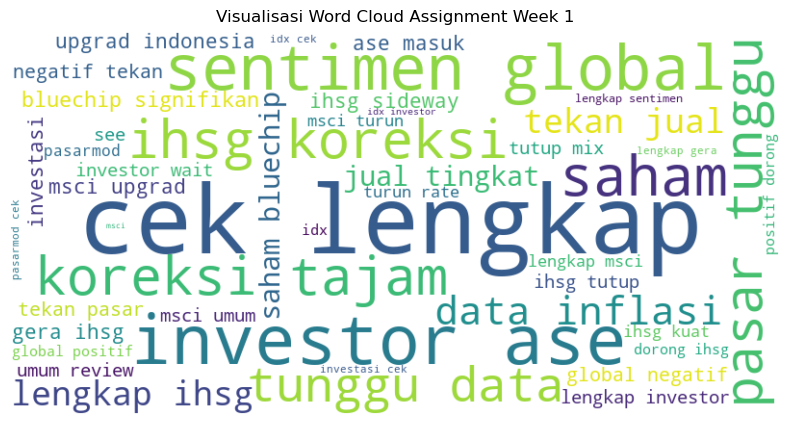

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from wordcloud import WordCloud

def plot_wordcloud(all_text):
    wordcloud = WordCloud(width=800, height=400, background_color='white').generate(all_text)
    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis('off')
    plt.title("Visualisasi Word Cloud Assignment Week 1")
    plt.show()

all_text = " ".join(df['Text'].astype(str))

plot_wordcloud(all_text)

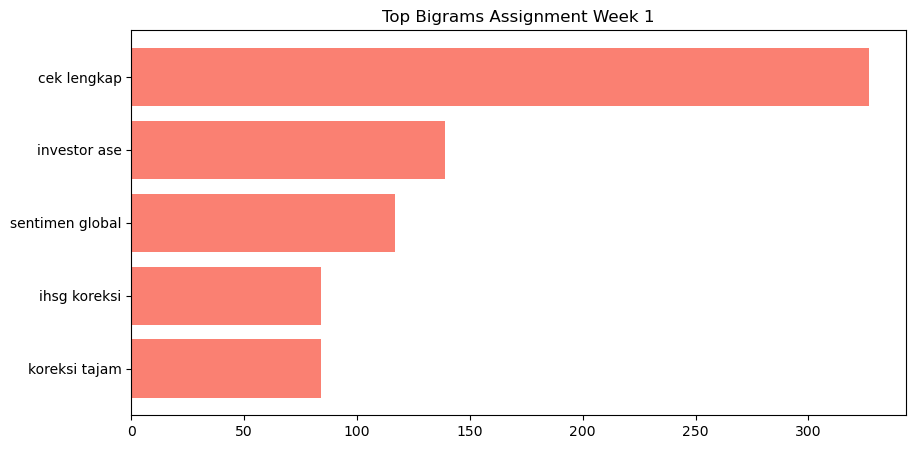

In [ ]:
from collections import Counter
def plot_bigrams(all_words):
    all_words = " ".join(df['Text'].astype(str)).split()
    bigrams = list(nltk.bigrams(all_words))
    bigram_counts = Counter(bigrams).most_common(5)

    # Ubah format tuple ('data', 'science') menjadi string 'data science'
    labels = [f"{b[0]} {b[1]}" for b, count in bigram_counts]
    values = [count for b, count in bigram_counts]

    plt.figure(figsize=(10, 5))
    plt.barh(labels, values, color='salmon')
    plt.gca().invert_yaxis()
    plt.title('Top Bigrams Assignment Week 1')
    plt.show()

plot_bigrams(all_words)

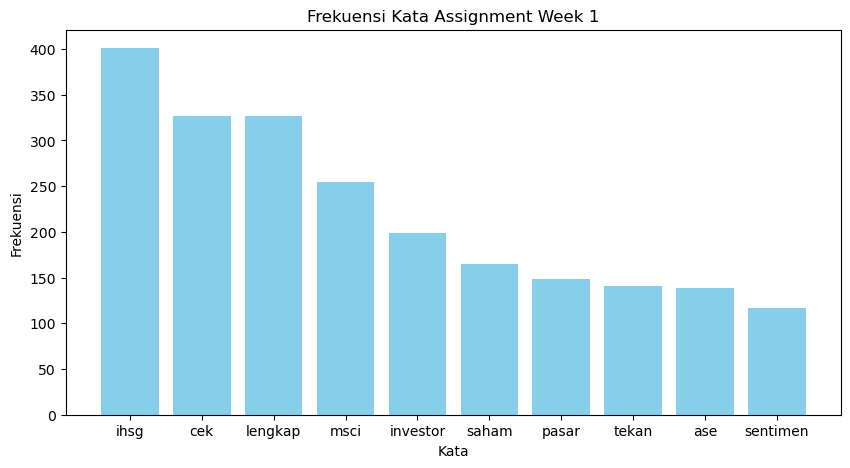

In [ ]:
from collections import Counter

def plot_bar_chart(df):
    all_words = " ".join(df['Text'].astype(str)).split()
    
    counts = Counter(all_words).most_common(10)

    word_labels, word_counts = zip(*counts)
    
    plt.figure(figsize=(10, 5))
    plt.bar(word_labels, word_counts, color='skyblue')
    plt.xlabel('Kata')
    plt.ylabel('Frekuensi')
    plt.title('Frekuensi Kata Assignment Week 1')
    plt.show()

plot_bar_chart(df)

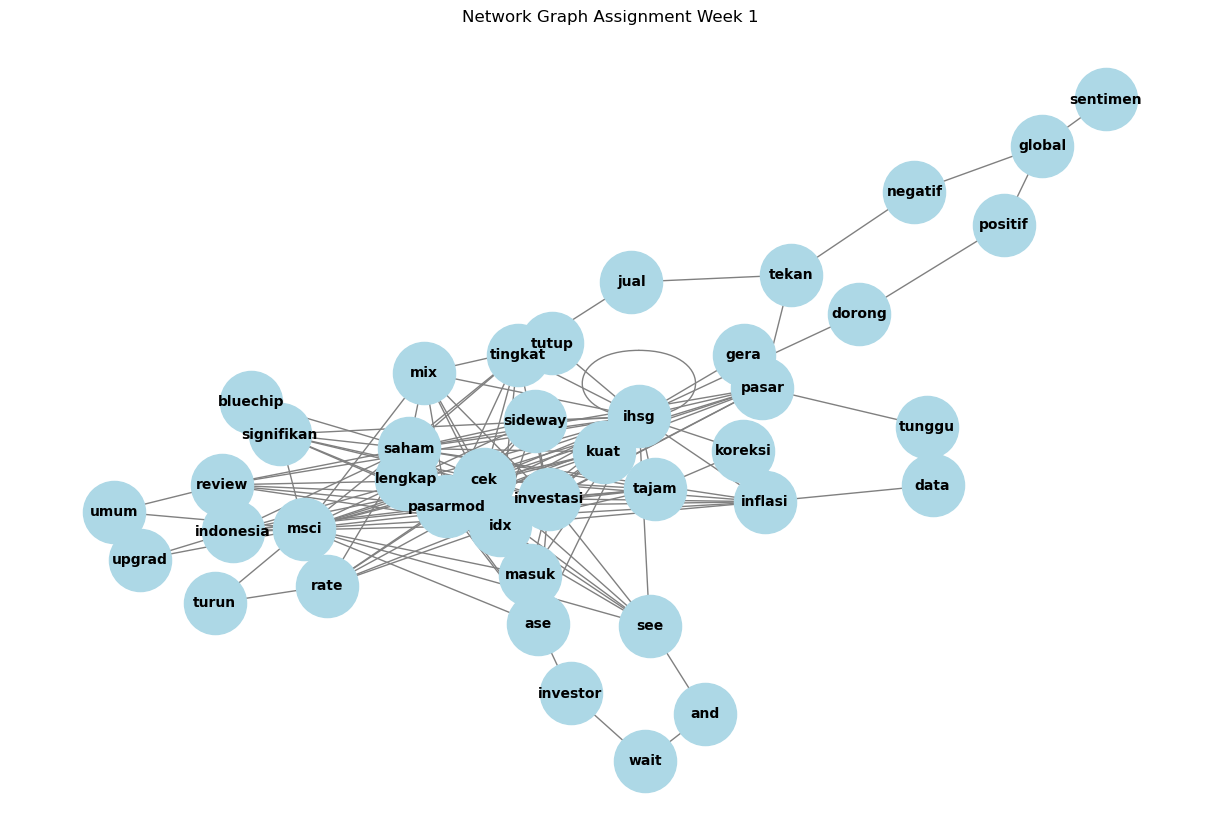

In [ ]:
#Lemmatization
import networkx as nx
import matplotlib.pyplot as plt

sentences = df['Text'].astype(str).tolist()

def plot_network_graph(sentences, stop_words):
    G = nx.Graph()

    for kalimat in sentences:
    
        words = kalimat.split()
        
        if len(words) > 1:
            for i in range(len(words) - 1):
                u = words[i]
                v = words[i+1]
                
                if G.has_edge(u, v):
                    G[u][v]['weight'] += 1
                else:
                    G.add_edge(u, v, weight=1)
                    
    plt.figure(figsize=(12, 8))

    pos = nx.spring_layout(G, k=0.5) 
    
    nx.draw(G, pos, with_labels=True, 
            node_color='lightblue', 
            node_size=2000, 
            font_size=10, 
            font_weight='bold', 
            edge_color='gray')

    plt.title("Network Graph Assignment Week 1")
    plt.show()

plot_network_graph(sentences, stopword)

# <p style="font-family:newtimeroman;font-size:150%;text-align:center;color:#8b4513;">Insights</p>

1. What words appear most frequently related to the JCI?

The words that appear most frequently is 'IHSG'. iT is followed by 'Cek' and 'Lengkap'. these two words ussualy come as a pair.

2. In your opinion, is sentiment predominantly positive or negative? Explain

The sentiment is somewhat balance, this is shown by the the sentiment of the comments are separated into three categories, neutral (537 tweets), positive (181 tweets), negative (282 tweets). Due to this, the sentinment is slighty in the negative side albeit not by much.


3. What are the implications of sentiment for capital market perception?

The implication seems to show that the investor are playing are leaning on going defensive than optimistic on the current state of the market. 